In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_df = pd.read_csv('../evaluations_full_02062025.csv')

In [4]:
evaluations_df['PT'] = np.where(
    evaluations_df['pretrain'].str.contains('Not', na=False),
    'Non-PT', 'PT'
)
evaluations_df['name'] = evaluations_df['PT'] + ' ' + evaluations_df['encoding'] + ' ' + evaluations_df['trained_blocks'].astype(str) + 'L'
evaluations_df = evaluations_df[evaluations_df['HLA'].isin(["A0201","B0702","B0801","B1801"])] 
# keep only the needed columns and drop rows without a spearman
cols = ["HLA", "name", "path", "spearman"]
df = evaluations_df[cols].dropna(subset=["spearman"]).copy()

# top 3 per (HLA, name) by spearman
top3_df = (
    df.sort_values("spearman", ascending=False)
      .groupby(["HLA", "name"], as_index=False, group_keys=False)
      .head(1000)
    #   .sort_values(["HLA", "name", "spearman", "path"], ascending=[True, True, False, True])
)

top3_df

,HLA,name,path,spearman
713,B1801,PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.881119
4917,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.825175
2570,B1801,Non-PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.818182
423,B1801,Non-PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.811189
3367,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.797203
...,...,...,...,...
622,B1801,PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.209790
1220,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.230769
7017,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.272727
7066,B1801,PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.279720


In [5]:
from scipy.stats import spearmanr, ttest_ind
import math
import re
from functools import reduce

# ============================================================================
# STEP 1: Load and filter to ensure exactly 3 models per regime
# ============================================================================

def ensure_3_reps_per_regime(top3_df):
    """
    Ensure we have exactly 3 replicates per regime (name) for each HLA.
    Takes top 3 by spearman correlation.
    
    Returns: filtered dataframe with exactly 3 rows per (HLA, name) combination
    """
    print("Original shape:", top3_df.shape)
    print("\nChecking replicates per regime per HLA:")
    
    filtered_rows = []
    
    for hla, hla_group in top3_df.groupby("HLA", sort=False):
        for name, name_group in hla_group.groupby("name", sort=False):
            # Sort by spearman (descending) and take top 3
            top_3 = name_group.sort_values("spearman", ascending=False).head(3)
            
            if len(top_3) < 3:
                print(f"  WARNING: {hla} | {name} has only {len(top_3)} models (need 3)")
            elif len(top_3) == 3:
                print(f"  ✓ {hla} | {name} has 3 models")
            
            filtered_rows.append(top_3)
    
    result = pd.concat(filtered_rows, ignore_index=True)
    print(f"\nFiltered shape: {result.shape}")
    
    # Verify the counts
    print("\nVerification - counts per (HLA, name):")
    counts = result.groupby(["HLA", "name"]).size()
    print(counts)
    print(f"\nAll have exactly 3? {(counts == 3).all()}")
    
    return result


# ============================================================================
# STEP 2: Load the data
# ============================================================================

# Assuming top3_df exists in your environment with columns: HLA, name, path, spearman
# If you need to load it from a file, uncomment and modify:
# top3_df = pd.read_csv("path_to_your_top3_file.csv")

# Filter to ensure exactly 3 replicates per regime
top3_df_filtered = ensure_3_reps_per_regime(top3_df)


# ============================================================================
# STEP 3: Loader function
# ============================================================================

def _load_predictions(path):
    """Load predictions from parquet or CSV file."""
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    measured_col = "measured" if "measured" in df.columns else None
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity","logit",
        "binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in file.")

    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)
    return d  # key, pred, [measured]


# ============================================================================
# STEP 4: Build wide table with replicates
# ============================================================================

def build_wide_by_hla_with_reps(top3_df):
    """
    Returns:
      wide_by_hla: {HLA: df with columns ['key', '<name> #1', '<name> #2', '<name> #3', ..., 'measured']}
      corr_by_hla: {HLA: Spearman correlation matrix across all columns except 'key'}
    """
    assert {"HLA","name","path","spearman"}.issubset(top3_df.columns)
    wide_by_hla = {}
    corr_by_hla  = {}

    for hla, sub_hla in top3_df.groupby("HLA", sort=False):
        cols = []
        measured_sources = []

        # Process each regime (name)
        for nm, sub_nm in sub_hla.groupby("name", sort=False):
            # Sort by spearman and take paths (should already be filtered to 3)
            picks = list(sub_nm.sort_values("spearman", ascending=False)["path"])
            
            if len(picks) != 3:
                print(f"[WARN] {hla} | {nm} has {len(picks)} paths, expected exactly 3.")

            for j, path in enumerate(picks, start=1):
                d = _load_predictions(path)
                cols.append(d[["key","pred"]].rename(columns={"pred": f"{nm} #{j}"}))
                if "measured" in d.columns:
                    measured_sources.append(d[["key","measured"]].copy())

        if not cols:
            continue

        wide = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), cols)

        # unify measured from all sources by coalescing left to right
        if measured_sources:
            ms = [m.rename(columns={"measured": f"m{i}"}) for i, m in enumerate(measured_sources)]
            mmerge = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), ms)
            # coalesce to a single measured column (take first non-NA)
            mcols = [c for c in mmerge.columns if c != "key"]
            mmerge["measured"] = mmerge[mcols].bfill(axis=1).iloc[:, 0]
            wide = wide.merge(mmerge[["key","measured"]], on="key", how="left")

        wide_by_hla[hla] = wide

        # correlation (pairwise complete obs), include measured if present
        pred_cols = [c for c in wide.columns if c != "key"]
        corr_by_hla[hla] = wide[pred_cols].corr(method="spearman")
        
        print(f"✓ Built wide table for {hla}: {wide.shape[0]} peptides, {len(pred_cols)} columns")

    return wide_by_hla, corr_by_hla


print("\n" + "="*80)
print("REBUILDING WIDE TABLES WITH 3 REPLICATES PER REGIME")
print("="*80 + "\n")

wide_by_hla, corr_by_hla = build_wide_by_hla_with_reps(top3_df_filtered)

print("\n" + "="*80)
print(f"Successfully built wide tables for {len(wide_by_hla)} HLAs")
print("="*80)

# Add diagnostic: check data overlap
print("\n" + "="*80)
print("DIAGNOSING DATA OVERLAP")
print("="*80 + "\n")

for hla, wide_df in wide_by_hla.items():
    print(f"\n{hla}:")
    print(f"  Total peptides: {len(wide_df)}")
    if "measured" in wide_df.columns:
        n_measured = wide_df['measured'].notna().sum()
        print(f"  Peptides with measured values: {n_measured}")
        
        model_cols = [c for c in wide_df.columns if c not in ['key', 'measured']]
        print(f"  Total model columns: {len(model_cols)}")
        
        # Check overlap for each model
        overlaps = {}
        for col in model_cols:
            both_present = (wide_df['measured'].notna() & wide_df[col].notna()).sum()
            overlaps[col] = both_present
        
        # Show summary
        overlap_counts = pd.Series(overlaps)
        print(f"  Models with ≥10 overlapping peptides: {(overlap_counts >= 10).sum()}/{len(model_cols)}")
        print(f"  Models with ≥5 overlapping peptides: {(overlap_counts >= 5).sum()}/{len(model_cols)}")
        print(f"  Models with ≥1 overlapping peptides: {(overlap_counts >= 1).sum()}/{len(model_cols)}")
        print(f"  Models with 0 overlapping peptides: {(overlap_counts == 0).sum()}/{len(model_cols)}")
    else:
        print(f"  No measured values available")

print("\n" + "="*80)


# ============================================================================
# STEP 5: Run comparison analysis
# ============================================================================

def extract_base_name(col_name):
    """Extract base model name from replicate column like 'ESMCBA #1' -> 'ESMCBA'"""
    match = re.match(r"^(.*)\s+#\d+$", col_name)
    return match.group(1) if match else col_name


def compare_model_regimes_bootstrap(wide_by_hla, n_bootstrap=1000):
    """
    Compare model regimes using bootstrap resampling on peptide-level predictions.
    This gives us error bars even when only 1 replicate has data!
    """
    comparison_results = {}
    
    for hla, wide_df in wide_by_hla.items():
        if "measured" not in wide_df.columns:
            continue
        
        model_cols = [c for c in wide_df.columns if c not in ['key', 'measured']]
        
        # Group replicates by base model name
        regime_to_reps = {}
        for col in model_cols:
            base = extract_base_name(col)
            regime_to_reps.setdefault(base, []).append(col)
        
        # Keep only regimes with exactly 3 replicates loaded
        regime_to_reps = {k: v for k, v in regime_to_reps.items() if len(v) == 3}
        
        if len(regime_to_reps) < 2:
            continue
        
        df_clean = wide_df.dropna(subset=['measured'])
        
        # Bootstrap correlations for each regime
        regime_bootstrap_corrs = {}
        regime_mean_corrs = {}
        
        for regime, rep_cols in regime_to_reps.items():
            # Combine all replicates' data into one pool for bootstrapping
            all_pairs = []
            
            for col in rep_cols:
                valid_mask = df_clean[col].notna()
                if valid_mask.sum() >= 1:
                    pairs = list(zip(
                        df_clean.loc[valid_mask, col].values,
                        df_clean.loc[valid_mask, 'measured'].values
                    ))
                    all_pairs.extend(pairs)
            
            if len(all_pairs) < 5:  # Need at least some data
                print(f"  SKIP: {hla} | {regime} has only {len(all_pairs)} peptide pairs total")
                continue
            
            # Bootstrap resample to get distribution of correlations
            bootstrap_corrs = []
            for _ in range(n_bootstrap):
                # Sample with replacement
                sample_indices = np.random.choice(len(all_pairs), size=len(all_pairs), replace=True)
                sample_pairs = [all_pairs[i] for i in sample_indices]
                
                pred_boot = [p[0] for p in sample_pairs]
                meas_boot = [p[1] for p in sample_pairs]
                
                corr, _ = spearmanr(pred_boot, meas_boot)
                bootstrap_corrs.append(corr)
            
            regime_bootstrap_corrs[regime] = np.array(bootstrap_corrs)
            regime_mean_corrs[regime] = np.mean(bootstrap_corrs)
            
            print(f"  ✓ {hla} | {regime}: ρ = {np.mean(bootstrap_corrs):.4f} ± {np.std(bootstrap_corrs):.4f} (from {len(all_pairs)} peptide pairs)")
        
        if len(regime_bootstrap_corrs) < 2:
            continue
        
        # Find best regime by mean
        best_name = max(regime_mean_corrs.items(), key=lambda x: x[1])[0]
        best_corrs = regime_bootstrap_corrs[best_name]
        
        # Compare to others
        other_comparisons = []
        for regime_name in sorted(regime_mean_corrs.keys(), 
                                  key=lambda x: regime_mean_corrs[x], reverse=True):
            if regime_name == best_name:
                continue
            
            other_corrs = regime_bootstrap_corrs[regime_name]
            
            # Two-sample t-test on bootstrap distributions
            t_stat, p_value = ttest_ind(best_corrs, other_corrs, alternative='greater')
            
            other_comparisons.append({
                'regime': regime_name,
                'bootstrap_corrs': other_corrs,
                'mean_corr': np.mean(other_corrs),
                'se': np.std(other_corrs),  # Bootstrap SE
                'diff': np.mean(best_corrs) - np.mean(other_corrs),
                't_statistic': t_stat,
                'p_value': p_value,
                'significant': p_value < 0.05
            })
        
        comparison_results[hla] = {
            'best_regime': best_name,
            'bootstrap_corrs': best_corrs,
            'best_corr': np.mean(best_corrs),
            'best_se': np.std(best_corrs),  # Bootstrap SE
            'other_regimes': other_comparisons
        }
    
    return comparison_results


print("\n" + "="*80)
print("RUNNING BOOTSTRAP REGIME COMPARISON (1000 iterations)")
print("="*80 + "\n")

comparison_results = compare_model_regimes_bootstrap(wide_by_hla, n_bootstrap=1000)

print(f"\n{'='*80}")
print(f"Bootstrap comparison results for {len(comparison_results)} HLAs")
print(f"{'='*80}")
for hla, result in comparison_results.items():
    print(f"\n{hla}:")
    print(f"  Best regime: {result['best_regime']} (ρ = {result['best_corr']:.4f} ± {result['best_se']:.4f})")
    print(f"  Compared against {len(result['other_regimes'])} other regimes:")
    for other in result['other_regimes']:
        sig_marker = " ***" if other['significant'] else ""
        print(f"    - {other['regime']}: ρ = {other['mean_corr']:.4f} ± {other['se']:.4f}{sig_marker}")


# ============================================================================
# STEP 6: Plot the results
# ============================================================================


Original shape: (410, 4)

Checking replicates per regime per HLA:
  ✓ B1801 | PT HLA 30L has 3 models
  ✓ B1801 | PT epitope 30L has 3 models
  ✓ B1801 | Non-PT HLA 30L has 3 models
  ✓ B1801 | Non-PT epitope 30L has 3 models
  ✓ B1801 | Non-PT epitope 0L has 3 models
  ✓ B1801 | Non-PT HLA 0L has 3 models
  ✓ B1801 | PT epitope 0L has 3 models
  ✓ B1801 | PT HLA 0L has 3 models
  ✓ B0702 | PT HLA 30L has 3 models
  ✓ B0702 | PT epitope 30L has 3 models
  ✓ B0702 | Non-PT epitope 30L has 3 models
  ✓ B0702 | Non-PT HLA 30L has 3 models
  ✓ B0702 | Non-PT epitope 0L has 3 models
  ✓ B0702 | Non-PT HLA 0L has 3 models
  ✓ B0702 | PT epitope 0L has 3 models
  ✓ B0702 | PT HLA 0L has 3 models
  ✓ A0201 | PT epitope 30L has 3 models
  ✓ A0201 | Non-PT HLA 30L has 3 models
  ✓ A0201 | Non-PT epitope 30L has 3 models
  ✓ A0201 | PT HLA 30L has 3 models
  ✓ A0201 | PT epitope 0L has 3 models
  ✓ A0201 | Non-PT epitope 0L has 3 models
  ✓ A0201 | Non-PT HLA 0L has 3 models
  ✓ A0201 | PT HLA 0L

In [18]:
curve_stats = pd.read_csv('../../data/curve_stats.csv')
stability_iqr = pd.read_csv('../../data/stability_iqr.csv')

/tmp/ipykernel_3378416/3820991885.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


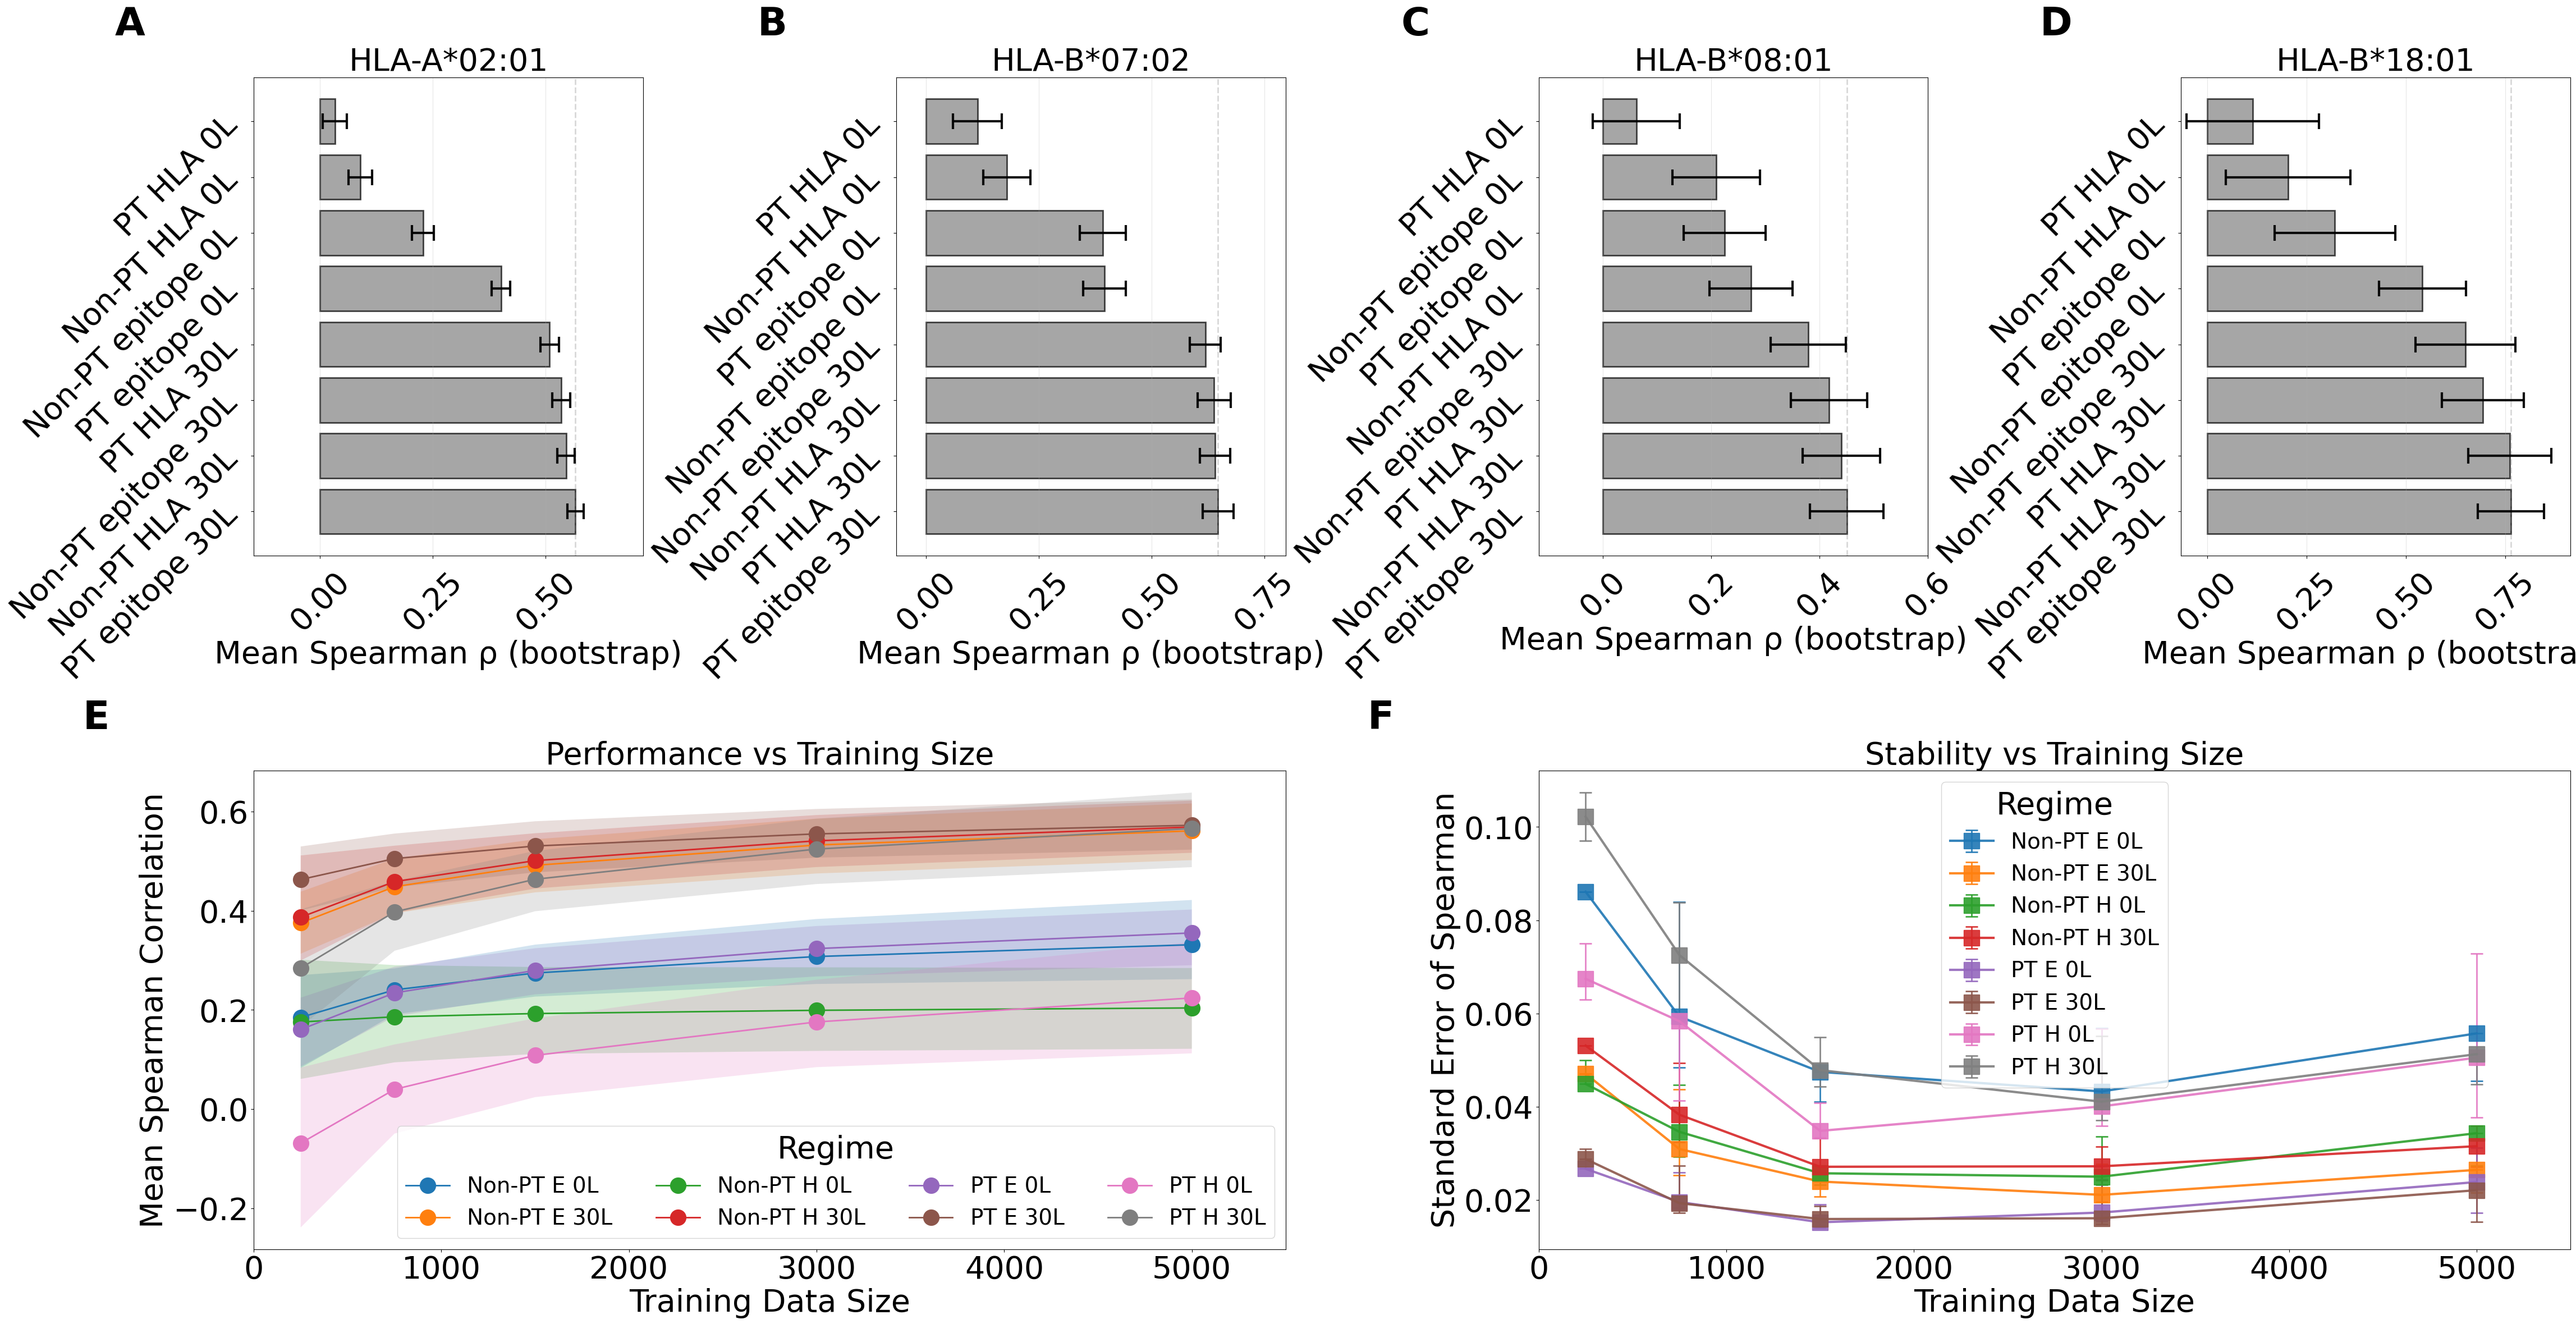

In [19]:
# Define color scheme
HIGHLIGHT_COLOR = '#808080'
GRAY_COLOR = '#808080'

# Create figure with custom layout
fig = plt.figure(figsize=(48, 24))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.45, wspace=0.65, 
                      left=0.12, right=0.98, top=0.95, bottom=0.08)

# ============================================================================
# ROW 1 (A-D): Four HLA Bootstrap Comparison Plots
# ============================================================================

target_hlas = sorted(["A0201", "B0702", "B0801", "B1801"])

for idx, hla in enumerate(target_hlas):
    ax = fig.add_subplot(gs[0, idx])
    
    if hla not in comparison_results:
        ax.text(0.5, 0.5, f"{hla}\nNo data available", 
               ha='center', va='center', transform=ax.transAxes, fontsize=40)
        ax.axis('off')
        continue
    
    data = comparison_results[hla]
    best_regime = data['best_regime']
    best_corr = data['best_corr']
    best_se = data['best_se']
    others = data['other_regimes']
    
    if not others:
        ax.text(0.5, 0.5, f"{hla}\nNo comparisons available", 
               ha='center', va='center', transform=ax.transAxes, fontsize=40)
        ax.axis('off')
        continue
    
    # Prepare data for plotting
    regime_names = [best_regime] + [o['regime'] for o in others]
    corrs = [best_corr] + [o['mean_corr'] for o in others]
    ses = [best_se] + [o['se'] for o in others]
    
    y_pos = np.arange(len(regime_names))
    
    # Color: only best model highlighted
    colors = [HIGHLIGHT_COLOR] + [GRAY_COLOR] * len(others)
    
    # Plot horizontal bars
    bars = ax.barh(y_pos, corrs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    
    # Add error bars for every model
    for i in range(len(corrs)):
        corr_val = corrs[i]
        se_val = ses[i]
        ax.errorbar(corr_val, i, xerr=se_val, fmt='none', 
                   ecolor='black', capsize=10, capthick=3, linewidth=3, alpha=0.95,
                   zorder=10)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(regime_names, fontsize=40)
    ax.set_xlabel('Mean Spearman ρ (bootstrap)', fontsize=40)
    hla_formatted = 'HLA-' + hla[0] + '*' + hla[1:3] + ':' + hla[3:]
    ax.set_title(f"{hla_formatted}", fontsize=40)
    
    # Adjust xlim
    ax.set_xlim([min(corrs) - 0.18, max(corrs) + 0.15])
    
    ax.axvline(best_corr, color=HIGHLIGHT_COLOR, linestyle='--', alpha=0.3, linewidth=2)
    ax.grid(axis='x', alpha=0.3, linewidth=0.8)
    ax.tick_params(axis='both', which='major', labelsize=40, pad=10, rotation=45)
    
    # Add panel label
    panel_label = chr(65 + idx)  # A, B, C, D
    ax.text(-0.28, 1.15, panel_label, transform=ax.transAxes,
            fontsize=50, va='top', ha='right', weight='bold')

# ============================================================================
# ROW 2 (E-F): Pooled Analysis Plots
# ============================================================================

# Update font sizes
plt.rcParams.update({
    "font.size": 40,
    "axes.titlesize": 40,
    "axes.labelsize": 40,
    "xtick.labelsize": 40,
    "ytick.labelsize": 40,
    "legend.fontsize": 28,
    "figure.titlesize": 40,
})

# Panel E: Performance vs Training Size
ax_e = fig.add_subplot(gs[1, 0:2])
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['train_size']).sort_values('train_size')
    if g.empty or g['mean'].isna().all():
        continue
    ax_e.plot(g['train_size'], g['mean'], marker='o', linewidth=2, markersize=20, label=regime)
    ax_e.fill_between(g['train_size'], g['ci_lower'], g['ci_upper'], alpha=0.20)

ax_e.set_xlabel('Training Data Size', fontsize=40)
ax_e.set_ylabel('Mean Spearman Correlation', fontsize=40)
ax_e.set_title('Performance vs Training Size', fontsize=40)
ax_e.grid(False)
ax_e.legend(title='Regime', fontsize=28, loc='best',ncol =4)
ax_e.set_xlim([0, 5500])
ax_e.tick_params(axis='both', which='major', labelsize=40)

# Add panel label E
ax_e.text(-0.14, 1.15, 'E', transform=ax_e.transAxes,
          fontsize=50, va='top', ha='right', weight='bold')

# Panel F: Stability
ax_f = fig.add_subplot(gs[1, 2:4])
for regime, g in stability_iqr.groupby('group_label'):
    g = g.dropna(subset=['train_size']).sort_values('train_size')
    if g.empty:
        continue
    
    # Calculate error from IQR
    g['error_lower'] = g['median_se'] - g['q25_se']
    g['error_upper'] = g['q75_se'] - g['median_se']
    
    # Plot with error bars
    ax_f.errorbar(g['train_size'], g['median_se'],
                  yerr=[g['error_lower'], g['error_upper']],
                  marker='s', linewidth=3, markersize=20,
                  capsize=8, capthick=2, elinewidth=2,
                  label=regime, alpha=0.9)

ax_f.set_xlabel('Training Data Size', fontsize=40)
ax_f.set_ylabel('Standard Error of Spearman', fontsize=40)
ax_f.set_title('Stability vs Training Size', fontsize=40)
ax_f.grid(False)
ax_f.legend(title='Regime', fontsize=28, loc='best')
ax_f.set_xlim([0, 5500])
ax_f.tick_params(axis='both', which='major', labelsize=40)

# Add panel label F
ax_f.text(-0.14, 1.15, 'F', transform=ax_f.transAxes,
          fontsize=50, va='top', ha='right', weight='bold')

# ============================================================================
# SAVE FIGURE
# ============================================================================

plt.tight_layout()
plt.savefig('../../figures_manuscript/3a_combined_regime_analysis.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [23]:
curve_stats[(curve_stats['group_label'] == 'PT E 30L' ) | (curve_stats['group_label'] == 'Non-PT E 30L' ) ]

,train_size,mean,ci_lower,ci_upper,n_bootstrap,group_label
5,250,0.462708,0.400225,0.529375,100,PT E 30L
6,750,0.504901,0.447051,0.555385,100,PT E 30L
7,1500,0.530305,0.477275,0.580167,100,PT E 30L
8,3000,0.554730,0.506858,0.604992,100,PT E 30L
9,5000,0.572093,0.523039,0.624149,100,PT E 30L
25,250,0.375194,0.313195,0.438246,100,Non-PT E 30L
26,750,0.448197,0.394709,0.505013,100,Non-PT E 30L
27,1500,0.491407,0.436867,0.543951,100,Non-PT E 30L
28,3000,0.532253,0.474968,0.585491,100,Non-PT E 30L
29,5000,0.560802,0.501790,0.616061,100,Non-PT E 30L
